# 📊 ImmoEliza Data Analysis Notebook - Team Horse - Soo

This is a notebook to conduct the individual data analysis of project ImmoEliza.

"Now that the data has been both collected and cleaned, let's move on to the analysis. Data Analysis focuses on what IS, and hopes to give insights to the state of the dataset and relationships within it. Each team member should put forward at least 2 visuals.

You must be able to answer following questions (with a vizualization if appropriate):

- How many observations and features/columns do you have?  
- What is the proportion of missing values per column?  
- Which variables would you delete and why?  
- What variables are most subject to outliers?  
- How many qualitative and quantitative variables are there? What are appropiate visuals for quantitative vs qualitative data? What are appropiate measures for correlations when dealing with qualitative and quantitative variables?  
- What is the correlation between the variables and the price? Why do you think some variables are more correlated than others?  
- How are the variables themselves correlated to each other? Can you find groups of variables that are correlated together?  
- How are the number of properties distributed according to their surface?  
- Which five variables do you consider the most important and why?  
- What are the least/most expensive municipalities in Belgium/Wallonia/Flanders? (in terms of price per m², average price, and median price)  

This is a non-exhaustive list of possible questions. Try to make a maximum number of interpretations from the dataset. Bonus points for creative and out-of-the-box insights.

Use tools such as matplotlib, seaborn, plotly, or [insert whatever visualization tool you find useful]...

Do your analysis in notebooks. No real need for scripting in this case, you'll want to have your hands free to experiment and explore the data in many directions. Writing functions for code you reuse is still a good idea, don't lose track of your good habits. Don't make it too messy though, your results should be reproducible and Immo Eliza's CEO might ask to rerun an analysis with a slight change :-)"

In [3]:
# Basic setup

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df_rent = pd.read_csv("../Data/Clean/RentCleanForAnalysis.csv")
df_sale = pd.read_csv("../Data/Clean/SaleCleanForAnalysis.csv")

### How many observations and features/columns do you have?

Observations = the number of rows  
Features = the number of columns

In [3]:
print("Rent CSV shape: ", df_rent.shape)
print("Sale CSV shape: ", df_sale.shape)

Rent CSV shape:  (3797, 25)
Sale CSV shape:  (9712, 25)


### What is the proportion of missing values per column?

In [ ]:
# For rent 
# missing_pct_rent = (df_rent.isna().mean() * 100).round(2) # mean of a bool col = true / number of rows
# missing_pct_sorted = missing_pct_rent.sort_values(ascending=False)
# missing_table = missing_pct_sorted.to_frame("Missing %")
# display(missing_table.style.format("{:.2f}%"))

# sns.barplot(
# 	x=missing_pct_sorted.values,
# 	y=missing_pct_sorted.index,
# )
# plt.show()

In [4]:
# Missing values / Rent / Appartment
missing_rent_apt = (df_rent[df_rent["property_type"] == "Appartment"].isna().mean() * 100).round(2)
missing_rent_apt_sorted = missing_rent_apt.sort_values(ascending=False)
missing_table_rent_apt = missing_rent_apt_sorted.to_frame("Missing %")
display(missing_table_rent_apt.style.format("{:.2f}%"))

,Missing %
land_surface,100.00%
garden,95.64%
swimming_pool,90.07%
garage,88.63%
balcony,85.02%
energy_consumption,76.16%
terrace,66.06%
date_of_construction,60.39%
availability,39.51%
property_condition,31.60%


In [5]:
# Missing values / Rent / House
missing_rent_hse = (df_rent[df_rent["property_type"] == "House"].isna().mean() * 100).round(2)
missing_rent_hse_sorted = missing_rent_hse.sort_values(ascending=False)
missing_table_rent_hse = missing_rent_hse_sorted.to_frame("Missing %")
display(missing_table_rent_hse.style.format("{:.2f}%"))

,Missing %
balcony,89.50%
swimming_pool,83.52%
energy_consumption,73.36%
garden,68.85%
terrace,65.91%
garage,65.35%
date_of_construction,60.84%
land_surface,54.63%
availability,41.08%
elevator,33.18%


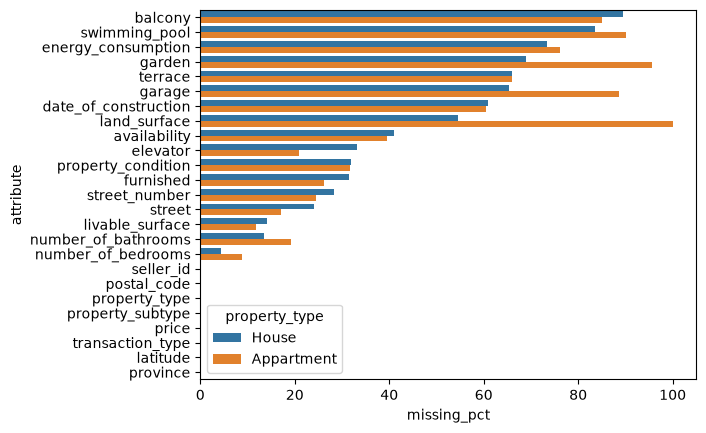

In [15]:
# Visualisation for missing values in Rent
rent_apt = (
	df_rent[df_rent["property_type"] == "Appartment"]
	.isna()
	.mean()
	.mul(100)
	.reset_index()
)
rent_apt.columns = ["attribute", "missing_pct"]
rent_apt["property_type"] = "Appartment"
rent_apt = rent_apt.sort_values("missing_pct", ascending=False)

rent_house = (
	df_rent[df_rent["property_type"] == "House"]
	.isna()
	.mean()
	.mul(100)
	.reset_index()
)
rent_house.columns = ["attribute", "missing_pct"]
rent_house["property_type"] = "House"
rent_house = rent_house.sort_values("missing_pct", ascending=False)

# Stack them together
rent_combined = pd.concat([rent_house, rent_apt], ignore_index=True)

sns.barplot(
	data=rent_combined,
	x="missing_pct",
	y="attribute",
	hue="property_type",
	orient="h"
)

plt.show()


In [ ]:
# # For sale
# missing_pct_sale = (df_sale.isna().mean() * 100).round(2)
# missing_pct_sorted = missing_pct_sale.sort_values(ascending=False)
# missing_table = missing_pct_sorted.to_frame("Missing %")
# display(missing_table.style.format("{:.2f}%"))

# sns.barplot(
# 	x=missing_pct_sorted.values,
# 	y=missing_pct_sorted.index,
# )
# plt.show()

In [6]:
# Missing values / Sale / Appartment
missing_sale_apt = (df_sale[df_sale["property_type"] == "Appartment"].isna().mean() * 100).round(2)
missing_sale_apt_sorted = missing_sale_apt.sort_values(ascending=False)
missing_table_sale_apt = missing_sale_apt_sorted.to_frame("Missing %")
display(missing_table_sale_apt.style.format("{:.2f}%"))

,Missing %
land_surface,100.00%
garden,93.89%
swimming_pool,89.77%
balcony,88.05%
garage,81.79%
energy_consumption,79.15%
availability,51.23%
terrace,51.20%
furnished,37.50%
date_of_construction,30.22%


In [7]:
# Missing values / Sale / House
missing_sale_hse = (df_sale[df_sale["property_type"] == "House"].isna().mean() * 100).round(2)
missing_sale_hse_sorted = missing_sale_hse.sort_values(ascending=False)
missing_table_sale_hse = missing_sale_hse_sorted.to_frame("Missing %")
display(missing_table_sale_hse.style.format("{:.2f}%"))

,Missing %
balcony,90.24%
swimming_pool,84.37%
energy_consumption,72.99%
terrace,67.77%
garden,65.72%
garage,55.08%
availability,42.12%
furnished,39.30%
date_of_construction,37.92%
elevator,31.94%


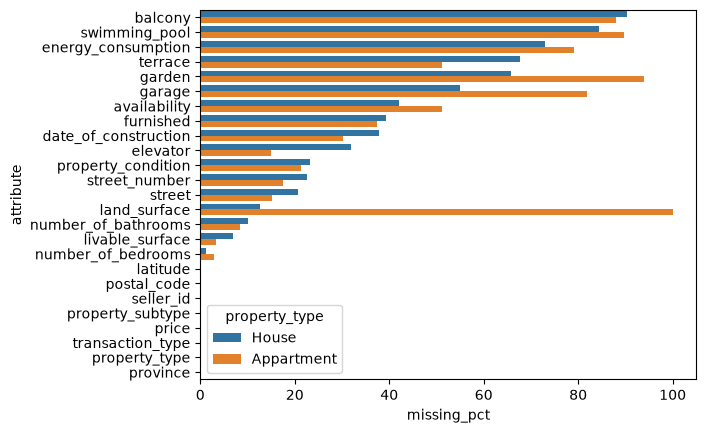

In [16]:
# Visualisation for Sale

# Visualisation for missing values in Sale
sale_apt = (
	df_sale[df_sale["property_type"] == "Appartment"]
	.isna()
	.mean()
	.mul(100)
	.reset_index()
)
sale_apt.columns = ["attribute", "missing_pct"]
sale_apt["property_type"] = "Appartment"
sale_apt = sale_apt.sort_values("missing_pct", ascending=False)

sale_house = (
	df_sale[df_sale["property_type"] == "House"]
	.isna()
	.mean()
	.mul(100)
	.reset_index()
)
sale_house.columns = ["attribute", "missing_pct"]
sale_house["property_type"] = "House"
sale_house = sale_house.sort_values("missing_pct", ascending=False)

# Stack them together
sale_combined = pd.concat([sale_house, sale_apt], ignore_index=True)

sns.barplot(
	data=sale_combined,
	x="missing_pct",
	y="attribute",
	hue="property_type",
	orient="h"
)

plt.show()


### Mapping Belgium

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


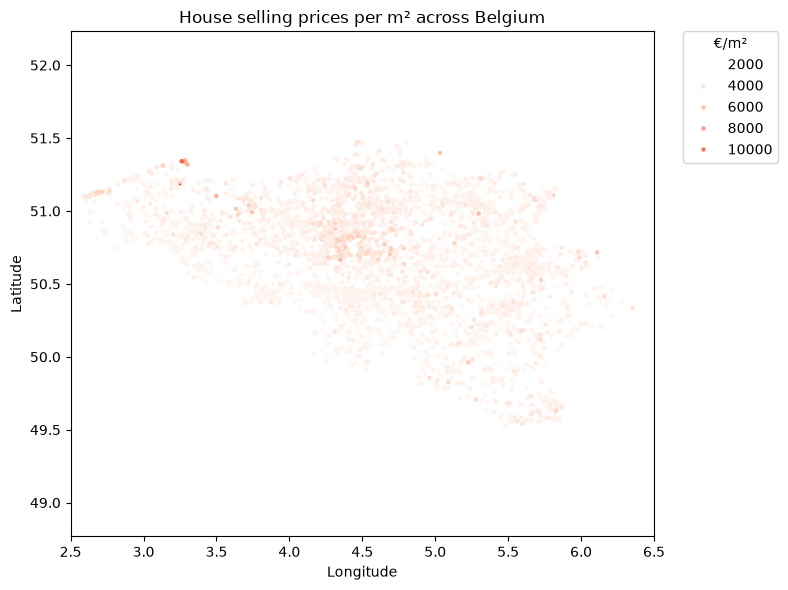

In [33]:
# Sale - House - price per square meter 
COMMON_MIN = 2000
COMMON_MAX = 16000

df_sale_house = df_sale[df_sale["property_type"] == "House"].copy()
df_sale_house["price_per_m2"] = df_sale_house["price"] / df_sale_house["livable_surface"]
# min_bound = df_sale_house["price_per_m2"].quantile(0.05)
# max_bound = df_sale_house["price_per_m2"].quantile(0.95)
min_bound = COMMON_MIN
max_bound = COMMON_MAX

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_sale_house,
    x="longitude",
    y="latitude",
    hue="price_per_m2",
    palette="Reds",
    s=8,
    alpha=0.8,
    edgecolor=None,
    hue_norm=(min_bound, max_bound)
)

plt.title("House selling prices per m² across Belgium")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="€/m²", bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
plt.axis("equal")
plt.tight_layout()
plt.xlim(2.5, 6.5)
plt.ylim(49.5, 51.5)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


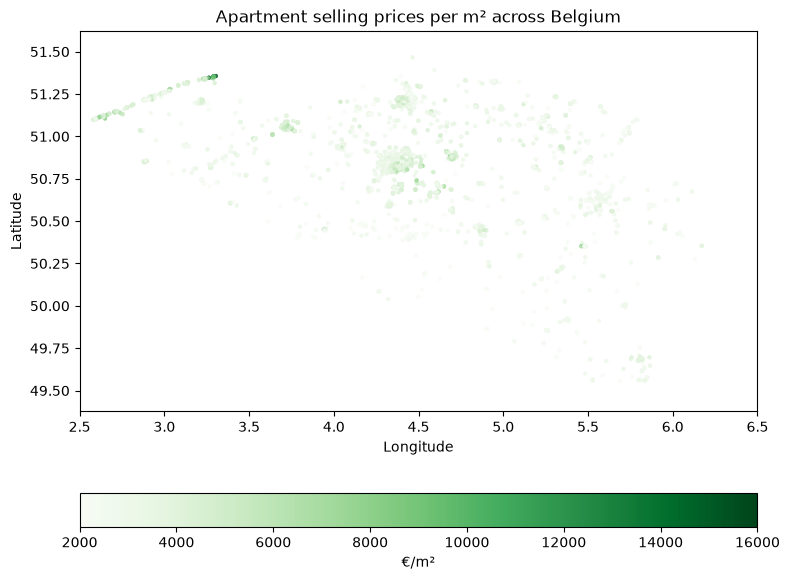

In [44]:
# Sale - Appartment - price per square meter 
from matplotlib.colors import Normalize

df_sale_apt = df_sale[df_sale["property_type"] == "Appartment"].copy()
df_sale_apt["price_per_m2"] = df_sale_apt["price"] / df_sale_apt["livable_surface"]
# min_bound = df_sale_apt["price_per_m2"].quantile(0.05)
# max_bound = df_sale_apt["price_per_m2"].quantile(0.95)
min_bound = COMMON_MIN
max_bound = COMMON_MAX
norm = Normalize(vmin=min_bound, vmax=max_bound)

plt.figure(figsize=(8, 6))

ax = sns.scatterplot(
    data=df_sale_apt,
    x="longitude",
    y="latitude",
    hue="price_per_m2",
    palette="Greens",
    s=8,
    alpha=0.7,
    edgecolor=None,
    hue_norm=norm,
    legend=False
)

sm = plt.cm.ScalarMappable(cmap="Greens", norm=norm)

plt.colorbar(sm, ax=ax, label="€/m²", orientation="horizontal")
plt.title("Apartment selling prices per m² across Belgium")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("equal")
plt.tight_layout()
plt.xlim(2.5, 6.5)
plt.ylim(49.5, 51.5)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


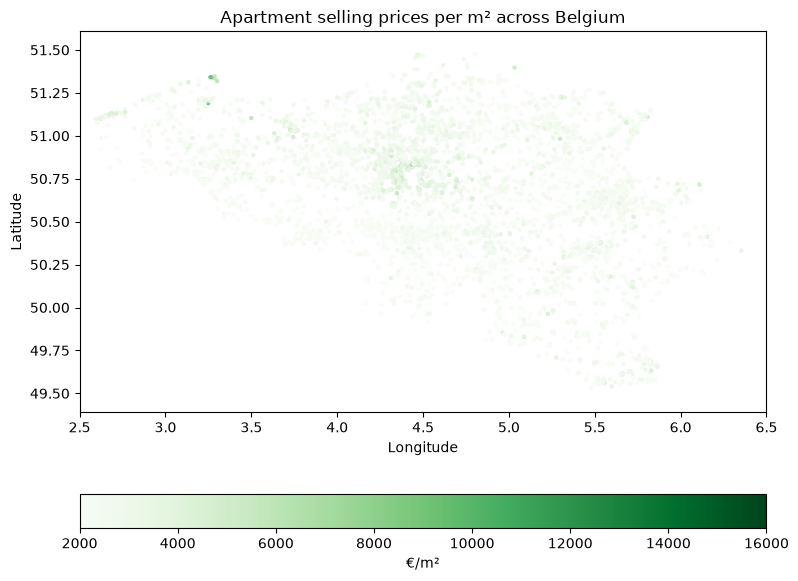

In [43]:
# Rent - House - price per square meter 

df_sale_house = df_sale[df_sale["property_type"] == "House"].copy()
df_sale_house["price_per_m2"] = df_sale_house["price"] / df_sale_house["livable_surface"]
# min_bound = df_sale_house["price_per_m2"].quantile(0.05)
# max_bound = df_sale_house["price_per_m2"].quantile(0.95)
min_bound = COMMON_MIN
max_bound = COMMON_MAX
norm = Normalize(vmin=min_bound, vmax=max_bound)

plt.figure(figsize=(8, 6))

ax = sns.scatterplot(
    data=df_sale_house,
    x="longitude",
    y="latitude",
    hue="price_per_m2",
    palette="Greens",
    s=8,
    alpha=0.7,
    edgecolor=None,
    hue_norm=norm,
    legend=False
)

sm = plt.cm.ScalarMappable(cmap="Greens", norm=norm)

plt.colorbar(sm, ax=ax, label="€/m²", orientation="horizontal")
plt.title("Apartment selling prices per m² across Belgium")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("equal")
plt.tight_layout()
plt.xlim(2.5, 6.5)
plt.ylim(49.5, 51.5)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


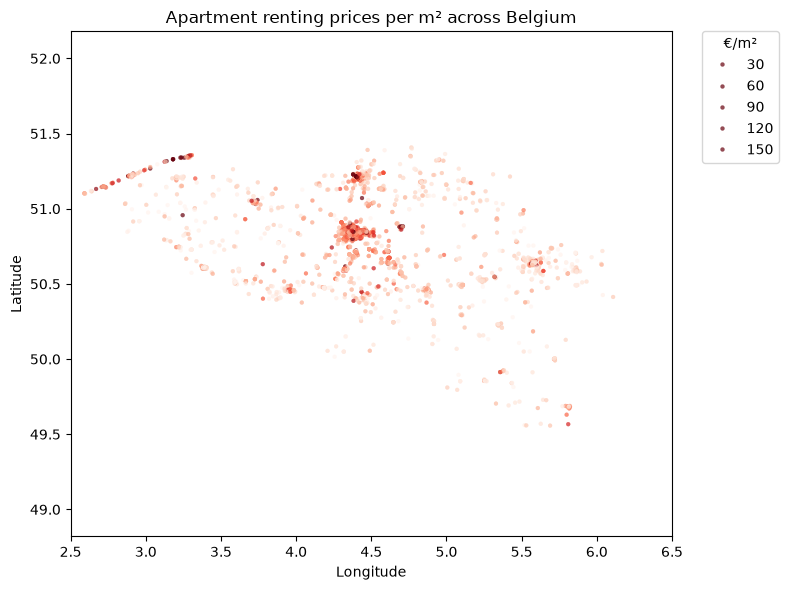

In [25]:
# Rent - Apartment - price per square meter 

df_rent_apt = df_rent[df_rent["property_type"] == "Appartment"].copy()
df_rent_apt["price_per_m2"] = df_rent_apt["price"] / df_rent_apt["livable_surface"]
min_bound = df_rent_apt["price_per_m2"].quantile(0.05)
max_bound = df_rent_apt["price_per_m2"].quantile(0.95)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_rent_apt,
    x="longitude",
    y="latitude",
    hue="price_per_m2",
    palette="Reds",
    s=8,
    alpha=0.7,
    edgecolor=None,
    hue_norm=(min_bound, max_bound)
)

plt.title("Apartment renting prices per m² across Belgium")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="€/m²", bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
plt.axis("equal")
plt.tight_layout()
plt.xlim(2.5, 6.5)
plt.ylim(49.5, 51.5)
plt.show()